## Imports and Data Loading

In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings('ignore')

train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')
sub   = pd.read_csv('../data/sample_submission.csv')

TARGET = 'addicted_label'
ID_COL = 'id'
NUM_COLS = ['age', 'daily_screen_time_hours', 'social_media_hours',
            'gaming_hours', 'work_study_hours', 'sleep_hours',
            'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
CAT_COLS = ['gender', 'stress_level', 'academic_work_impact']

print(f"Train: {train.shape} | Test: {test.shape}")

Train: (691369, 14) | Test: (296302, 13)


## Feature Engineering

In [2]:
def feature_engineering(df):
    df = df.copy()

    # Missing count 
    df['missing_count'] = df[NUM_COLS + CAT_COLS].isnull().sum(axis=1)

    # Missingness per group 
    df['missing_num_count'] = df[NUM_COLS].isnull().sum(axis=1)
    df['missing_cat_count'] = df[CAT_COLS].isnull().sum(axis=1)

    # Aggregates 
    active_cols = ['social_media_hours', 'gaming_hours', 'work_study_hours']
    df['total_active_hours'] = df[active_cols].sum(axis=1, min_count=1)
    df['passive_screen_time'] = df['daily_screen_time_hours'] - df['total_active_hours']

    # Ratios 
    eps = 1e-9
    df['social_ratio'] = df['social_media_hours'] / (df['daily_screen_time_hours'] + eps)
    df['gaming_ratio'] = df['gaming_hours'] / (df['daily_screen_time_hours'] + eps)
    df['work_ratio'] = df['work_study_hours'] / (df['daily_screen_time_hours'] + eps)
    df['screen_to_sleep'] = df['daily_screen_time_hours'] / (df['sleep_hours'] + eps)
    df['weekend_vs_daily'] = df['weekend_screen_time'] / (df['daily_screen_time_hours'] + eps)

    #  Intensity 
    df['app_opens_per_hour']   = df['app_opens_per_day']       / (df['daily_screen_time_hours'] + eps)
    df['notif_per_hour']       = df['notifications_per_day']   / (df['daily_screen_time_hours'] + eps)
    df['notif_per_app_open']   = df['notifications_per_day']   / (df['app_opens_per_day'] + eps)

    # Flags (Preserving NaNs so LGBM handles them properly)
    df['sleep_deprived'] = np.where(df['sleep_hours'].isna(), np.nan, (df['sleep_hours'] < 6).astype(float))
    df['very_sleep_deprived'] = np.where(df['sleep_hours'].isna(), np.nan, (df['sleep_hours'] < 5).astype(float))
    df['heavy_screen_user'] = np.where(df['daily_screen_time_hours'].isna(), np.nan, (df['daily_screen_time_hours'] > 8).astype(float))
    df['heavy_social_user'] = np.where(df['social_media_hours'].isna(), np.nan, (df['social_media_hours'] > 3).astype(float))
    df['high_notifications'] = np.where(df['notifications_per_day'].isna(), np.nan, (df['notifications_per_day'] > 150).astype(float))

    # Define components
    COMP = ['social_media_hours', 'gaming_hours', 'work_study_hours']
    daily = df['daily_screen_time_hours']

    # 1. Basic sums
    df['total_breakdown_hours'] = df[COMP].sum(axis=1, min_count=1)
    slack = daily - df['total_breakdown_hours']

    # 2. Boolean missingness logic
    n_missing_components = df[COMP].isna().sum(axis=1)
    missing_daily = daily.isna()

    daily_missing_with_components = missing_daily & (n_missing_components == 0)
    one_component_missing = (~missing_daily) & (n_missing_components == 1)
    all_screen_known = (~missing_daily) & (n_missing_components == 0)

    # 3. Create the "CI" / Slack features
    df['ci_daily_lb']         = np.where(daily_missing_with_components, df['total_breakdown_hours'], np.nan)
    df['ci_missing_comp_ub']  = np.where(one_component_missing, slack, np.nan)
    df['ci_missing_comp_mid'] = np.where(one_component_missing, np.clip(slack / 2, 0, None), np.nan)
    df['ci_slack_exact']      = np.where(all_screen_known, slack, np.nan)

    # 4. Categorical case tracker
    df['ci_case'] = np.select([daily_missing_with_components, one_component_missing], [1.0, 2.0], default=0.0).astype('float32')

    return df

train = feature_engineering(train)
test  = feature_engineering(test)

CAT_COLS.append('ci_case')

## Encode Categorical features

In [3]:
# stress_level: ordinal mapping preserves order
stress_map = {'Low': 0, 'Medium': 1, 'High': 2}
train['stress_level'] = train['stress_level'].map(stress_map)
test['stress_level']  = test['stress_level'].map(stress_map)

# gender & academic_work_impact: label encode
for col in ['gender', 'academic_work_impact']:
    combined = pd.concat([train[col], test[col]], axis=0).fillna('Unknown').astype(str)
    codes     = {v: i for i, v in enumerate(combined.unique())}
    train[col] = train[col].fillna('Unknown').astype(str).map(codes)
    test[col]  = test[col].fillna('Unknown').astype(str).map(codes)

# Cast these to proper Pandas Category dtype so LightGBM recognizes them!
for col in CAT_COLS:
    train[col] = train[col].astype('category')
    test[col]  = test[col].astype('category')

print(train[CAT_COLS].dtypes)
print(test[CAT_COLS].dtypes)

gender                  category
stress_level            category
academic_work_impact    category
ci_case                 category
dtype: object
gender                  category
stress_level            category
academic_work_impact    category
ci_case                 category
dtype: object


## Frequency Encoding

In [4]:
# Safe to do globally as it doesn't use the target variable
freq_enc_features = []

for col in NUM_COLS:
    fe_col = f'{col}_freq'

    train_str = train[col].astype(str)   # NaN → "nan"
    test_str  = test[col].astype(str)

    combined_counts = pd.concat([train_str, test_str], axis=0).value_counts()

    train[fe_col] = train_str.map(combined_counts).fillna(0).astype(int)
    test[fe_col]  = test_str.map(combined_counts).fillna(0).astype(int)

    freq_enc_features.append(fe_col)

print(f"Added {len(freq_enc_features)} frequency-encoded features")

Added 9 frequency-encoded features


## Prepare all the features

In [5]:
# Pre-allocate target-encoded columns with NaNs so they get included in FEATURES
te_features = [f'{col}_target_enc' for col in NUM_COLS]
for col in te_features:
    train[col] = np.nan
    test[col] = np.nan

DROP_COLS = [ID_COL, TARGET]
FEATURES = [c for c in train.columns if c not in DROP_COLS]

print(f"\nTotal features: {len(FEATURES)}")
print(FEATURES)

X = train[FEATURES]
y = train[TARGET]
X_test = test[FEATURES]


Total features: 54
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact', 'missing_count', 'missing_num_count', 'missing_cat_count', 'total_active_hours', 'passive_screen_time', 'social_ratio', 'gaming_ratio', 'work_ratio', 'screen_to_sleep', 'weekend_vs_daily', 'app_opens_per_hour', 'notif_per_hour', 'notif_per_app_open', 'sleep_deprived', 'very_sleep_deprived', 'heavy_screen_user', 'heavy_social_user', 'high_notifications', 'total_breakdown_hours', 'ci_daily_lb', 'ci_missing_comp_ub', 'ci_missing_comp_mid', 'ci_slack_exact', 'ci_case', 'age_freq', 'daily_screen_time_hours_freq', 'social_media_hours_freq', 'gaming_hours_freq', 'work_study_hours_freq', 'sleep_hours_freq', 'notifications_per_day_freq', 'app_opens_per_day_freq', 'weekend_screen_time_freq', 'age_target_enc', 'daily_screen_time_hours_target_enc', 'socia

## Cross Validation training

In [6]:
N_FOLDS = 5

LGBM_PARAMS = {
    'objective' : 'binary',
    'metric' : 'auc',
    'boosting_type' : 'gbdt',
    'n_estimators' : 10000,
    'learning_rate' : 0.01,
    'num_leaves' : 127,
    'max_depth' : -1,
    'min_child_samples' : 200,
    'feature_fraction' : 0.34,
    'bagging_fraction' : 0.75,
    'bagging_freq' : 5,
    'reg_alpha' : 0.1,
    'reg_lambda' : 1.0,
    'random_state' : 42,
    'n_jobs' : -1,
    'verbose' : -1,
    'max_bin': 1023,
}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores= []
models = []

global_mean = y.mean()
smoothing = 30

print("=" * 60)
print(f"  LightGBM — Stratified {N_FOLDS}-Fold CV")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train = X.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    X_test_fold = X_test.copy()

    # --- TARGET ENCODING (STRICTLY ON TRAIN FOLD, to prevent leakage) ---
    for col in NUM_COLS:
        te_col = f'{col}_target_enc'

        fold_map = (
            X_train.assign(target=y_train, _str=X_train[col].astype(str))
            .groupby('_str')['target']
            .agg(['mean', 'count'])
        )

        fold_map['te'] = (
            (fold_map['mean'] * fold_map['count'] + global_mean * smoothing)
            / (fold_map['count'] + smoothing)
        )
        te_map = fold_map['te'].to_dict()

        X_train[te_col] = X_train[col].astype(str).map(te_map).fillna(global_mean)
        X_val[te_col] = X_val[col].astype(str).map(te_map).fillna(global_mean)
        X_test_fold[te_col] = X_test_fold[col].astype(str).map(te_map).fillna(global_mean)


    for col in CAT_COLS:
        X_train[col] = X_train[col].astype('category')
        X_val[col] = X_val[col].astype('category')
        X_test_fold[col] = X_test_fold[col].astype('category')

    # --- TRAIN MODEL ---
    model = lgb.LGBMClassifier(**LGBM_PARAMS)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=500, verbose=False),
            lgb.log_evaluation(period=300)
        ]
    )

    val_pred           = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_pred
    fold_auc           = roc_auc_score(y_val, val_pred)
    fold_scores.append(fold_auc)

    test_preds        += model.predict_proba(X_test_fold)[:, 1] / N_FOLDS
    models.append(model)

    print(f"  Fold {fold}  |  Best iter: {model.best_iteration_:>5}  |  AUC: {fold_auc:.5f}")

print("=" * 60)
oof_auc = roc_auc_score(y, oof_preds)
print(f"  OOF AUC  : {oof_auc:.5f}")
print(f"  Mean CV  : {np.mean(fold_scores):.5f}  ±  {np.std(fold_scores):.5f}")
print("=" * 60)

  LightGBM — Stratified 5-Fold CV
[300]	valid_0's auc: 0.962466
[600]	valid_0's auc: 0.965345
[900]	valid_0's auc: 0.966515
[1200]	valid_0's auc: 0.967068
[1500]	valid_0's auc: 0.967392
[1800]	valid_0's auc: 0.967566
[2100]	valid_0's auc: 0.967654
[2400]	valid_0's auc: 0.967731
[2700]	valid_0's auc: 0.967791
[3000]	valid_0's auc: 0.967828
[3300]	valid_0's auc: 0.967852
[3600]	valid_0's auc: 0.967873
[3900]	valid_0's auc: 0.967896
[4200]	valid_0's auc: 0.967906
[4500]	valid_0's auc: 0.967924
[4800]	valid_0's auc: 0.967932
[5100]	valid_0's auc: 0.96793
[5400]	valid_0's auc: 0.967935
[5700]	valid_0's auc: 0.967922
  Fold 1  |  Best iter:  5245  |  AUC: 0.96794
[300]	valid_0's auc: 0.963024
[600]	valid_0's auc: 0.966057
[900]	valid_0's auc: 0.967272
[1200]	valid_0's auc: 0.967846
[1500]	valid_0's auc: 0.968184
[1800]	valid_0's auc: 0.968375
[2100]	valid_0's auc: 0.968483
[2400]	valid_0's auc: 0.968543
[2700]	valid_0's auc: 0.968598
[3000]	valid_0's auc: 0.968627
[3300]	valid_0's auc: 0.968

## Feature importance

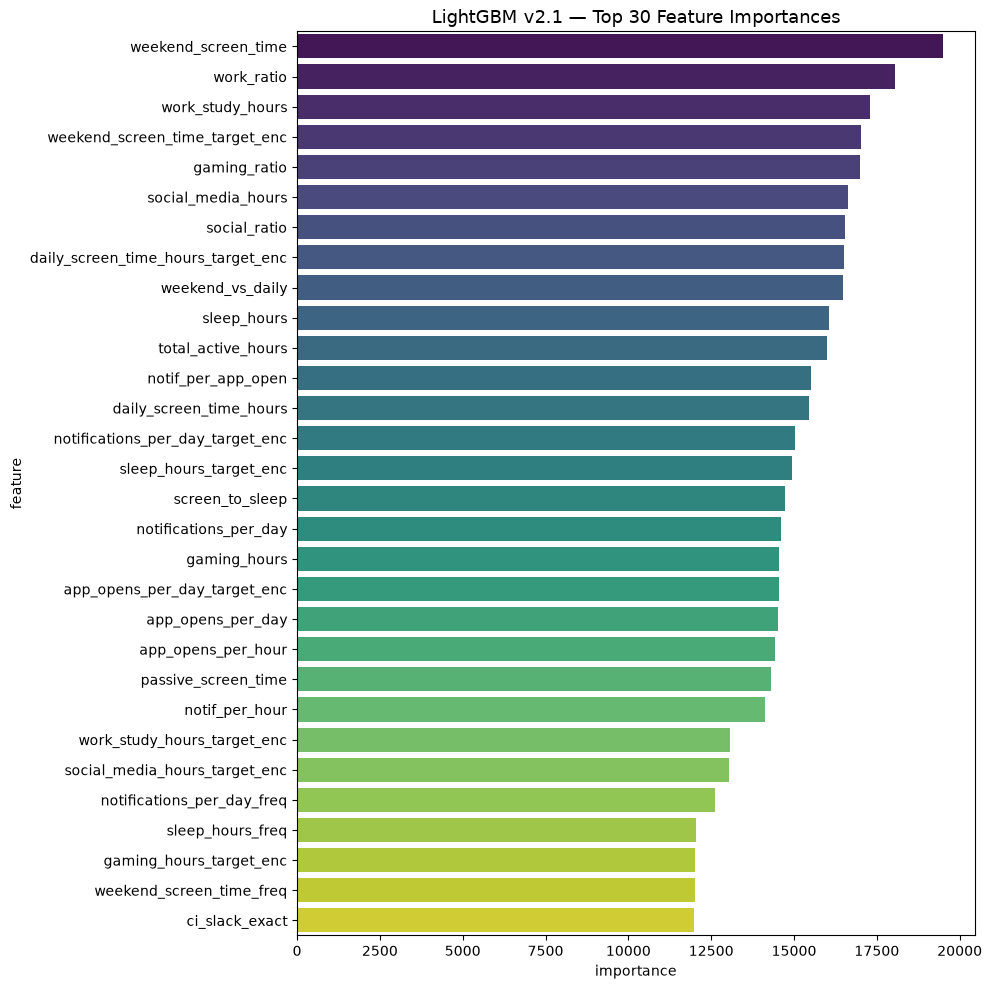


Top 15 features:
                           feature  importance
               weekend_screen_time     19483.2
                        work_ratio     18059.8
                  work_study_hours     17299.2
    weekend_screen_time_target_enc     17024.2
                      gaming_ratio     17002.0
                social_media_hours     16639.8
                      social_ratio     16544.6
daily_screen_time_hours_target_enc     16521.4
                  weekend_vs_daily     16490.4
                       sleep_hours     16042.4
                total_active_hours     16004.2
                notif_per_app_open     15509.0
           daily_screen_time_hours     15458.6
  notifications_per_day_target_enc     15028.2
            sleep_hours_target_enc     14936.6


In [7]:
importance_df = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': np.mean([m.feature_importances_ for m in models], axis=0)
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(data=importance_df.head(30), x='importance', y='feature', palette='viridis')
plt.title('LightGBM v2.1 — Top 30 Feature Importances', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance_v2_1.png', dpi=150)
plt.show()

print("\nTop 15 features:")
print(importance_df.head(15).to_string(index=False))

## OOF Distribution

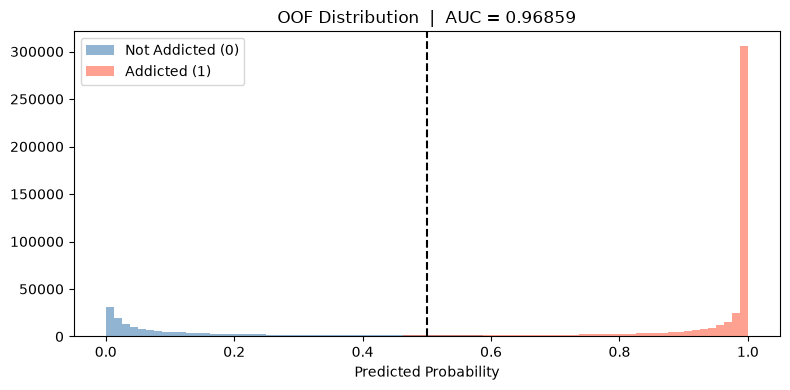

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(oof_preds[y == 0], bins=80, alpha=0.6, label='Not Addicted (0)', color='steelblue')
plt.hist(oof_preds[y == 1], bins=80, alpha=0.6, label='Addicted (1)',     color='tomato')
plt.axvline(0.5, color='black', linestyle='--')
plt.title(f'OOF Distribution  |  AUC = {oof_auc:.5f}')
plt.xlabel('Predicted Probability')
plt.legend()
plt.tight_layout()
plt.show()

## Save OOF

In [9]:
oof = pd.DataFrame(oof_preds)
oof.columns = ['addicted_label']
oof.to_csv('../submissions/oof_preds.csv', index=False)
print("\noof_preds.csv saved!\n")
oof.head()


oof_preds.csv saved!



,addicted_label
0,0.919004
1,0.045847
2,0.230310
3,0.202842
4,0.999975


## Submission

In [10]:
sub['addicted_label'] = test_preds
sub.to_csv('../submissions/submission_lgbm.csv', index=False)

print("\nsubmission_lgbm.csv saved!\n")
display(sub.head())
print(f"\nPred range : [{test_preds.min():.4f}, {test_preds.max():.4f}]")
print(f"Pred mean  : {test_preds.mean():.4f}")


submission_lgbm.csv saved!



,id,addicted_label
0,691369,0.999833
1,691370,0.963528
2,691371,0.811496
3,691372,0.995291
4,691373,0.999188



Pred range : [0.0002, 1.0000]
Pred mean  : 0.7102
